# Problem 6 - Phase Identification(2)

## Agenda
- Problem Description
- Problem Implementation
- Wrap-Up

## Problem Description
- <b>Consider a grid for which we do not have sufficient metering data $z_{meter}$ and estimate the state vector $x$ that fully characterizes the condition in which the grid is operated,given the grid static information of its structure and corresponding component models, and the standard measurement values of all grid connected loads.
    
    -<b>Let us use the four-bus radial feeder system of the previous example and assume we have access to real-time voltage measurements on bus k (as before). Assuming pseudo-measurements on per-phase load currents are available, we want to estimate the remaining feeder bus voltages.

Considered network
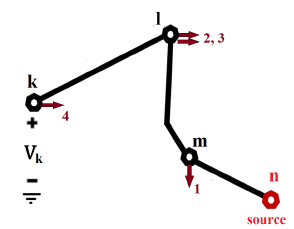

<b>Import Python Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [12]:
cosPhi=0.95
#time=48
m=12
netFactor=0.25
#noiseFactor=0.005

<b>Initial data

In [13]:
#Consumption dataset
s=  [[0.0450,    0.0150,    0.0470,    0.0330],
     [0.0250,    0.0150,    0.2480,    0.0330],
     [0.0970,    0.0250,    0.3940,    0.0330],
     [0.0700,    0.0490,    0.0200,    0.4850],
     [0.1250,    0.0460,    0.0160,    0.1430],
     [0.2900,    0.0270,    0.0160,    0.0470],
     [0.2590,    0.0150,    0.0170,    0.0200],
     [0.2590,    0.0160,    0.0280,    0.0160],
     [0.4420,    0.0160,    0.0500,    0.0170],
     [0.2010,    0.0230,    0.0460,    0.0160],
     [0.2060,    0.0490,    0.0220,    0.0240],
     [0.1300,    0.0470,    0.0160,    0.0490],
     [0.0460,    0.0260,    0.0170,    0.0480]]
s = np.array(s)

#topology
topo=[[1, 2],[2,3],[3,4]]
nBUS=np.max(topo)

#Impedance
z=np.multiply([complex(0.1,0.05),complex(0.15,0.07),complex(0.2,0.1)],netFactor)

vr=1 #Reference voltage
el=1
ni=20 #Iterations for the Power Flow




<b>Power Flow Function

In [14]:
def pf3ph(t,z,si,vr,el,ni,al):
    #Matrices creation
    t=np.array(t)
    p=t[:,0]
    f=t[:,1]
    w=len(p)+1
    vp=np.zeros((nBUS-1,w), dtype=complex)
    vn=np.zeros((nBUS-1,w), dtype=complex)
    vp[0,0:w]=vr
    
    for h in range (2,nBUS):
        vp[h-1,:]=vp[h-2,:]*al  #Create a three phase system of voltages
                                #Voltages will be the same in all BUS

    va=vp-vn                                                      #Auxiliar voltage
    ia=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))      #Auxiliar current 
    
    for it in range(ni):                                          #Iterations of Power Flow
        va=vp-vn
        ip=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))  #Phase current 
        inn=-np.sum(ip,0)                                         #Neutral current 

        for k in range(w-1,0,-1):                                 #Backward Cycle
            n=f[k-1]
            m=p[k-1]
            ip[:,m-1]=ip[:,m-1]+ip[:,n-1]                         #Phase Current
            inn=-np.sum(ip,0)                                     #Neutral Current

        eps= np.linalg.norm(np.max(np.abs(ia-ip),0))              #Error, comparing the new currents and the old ones (previous iteration)

        if eps>1e-4:
            ia=ip
            mvp=0
            mvn=0
            eps=np.inf
        else:                       #If the error is lower than the limit, we can return the results 
            mvp=(vp-vn)             #Phase Voltages to return
            mvn=vn[0,:]             #Neutral Voltage to return
#            return mvp, mvn, eps, ip, inn;
            return mvp, ip;
        for k in range (w-1):                     #Forward Cycle
            n=f[k]                                
            m=p[k]
            vn[:,n-1]=vn[:,m-1]-z[k]*inn[n-1]     #Neutral Voltage 
            vp[:,n-1]=vp[:,m-1]-z[k]*ip[:,n-1]    #Phase Voltage
        ia=ip             #Save the current of previous iteration

<b>Compute the values of voltages in function of currents

In [15]:
al=np.exp(np.multiply(np.multiply(complex(0,-1),2/3),np.pi)) #Phase Angle
sp=np.mean(s[0:m,:], axis=0) #Average power in each phase (i0)

si=[[0, 0, sp[2], 0],[0, 0, sp[1], 0],[0, sp[0],  0, sp[3]]] #Power in each bus and in each phase

mvp, ip=pf3ph(topo,z,si,vr,el,ni,al)  #Compute the power flow

zv=mvp[:,3]    #Voltage Measurement in Node 4 

print('The values of the currents are:\n',ip)

The values of the currents are:
 [[ 0.07666399-0.00064047j  0.07666399-0.00064047j  0.07666399-0.00064047j
   0.        -0.j        ]
 [-0.0141556 -0.02483195j -0.0141556 -0.02483195j -0.0141556 -0.02483195j
  -0.        +0.j        ]
 [-0.12640751+0.22194277j -0.12640751+0.22194277j -0.03759005+0.06643618j
  -0.03759005+0.06643618j]]


<b>State Estimation
   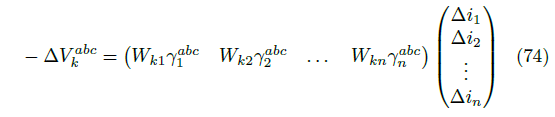
    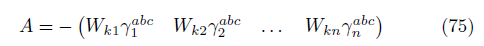
    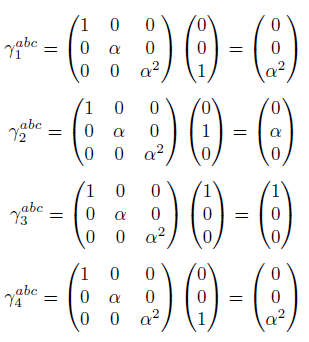
    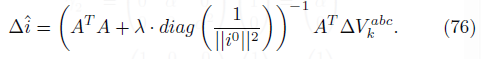

In [16]:
# ── Build matrix A ────────────────────────────────────────────────────────────
# From eq. (79): A = -[W_k1 γ_1^abc  W_k2 γ_2^abc  ...  W_kn γ_n^abc]
#
# W is the 3×3 impedance weighting matrix (same for all branches here),
# and γ_i^abc selects the right column of the rotation matrix depending
# on which phase load i is connected to.
#
# The rotation matrix diag(1, α, α²) converts single-phase current
# into the three-phase reference frame.  γ_i = diag(1,α,α²) · β_i,
# where β_i is the one-hot phase-selection vector.
#
# Phase connections: load1→c, load2→b, load3→a, load4→c
#   γ_1 = [0, 0, α²]ᵀ   (phase c)
#   γ_2 = [0, α, 0 ]ᵀ   (phase b)
#   γ_3 = [1, 0, 0 ]ᵀ   (phase a)
#   γ_4 = [0, 0, α²]ᵀ   (phase c)
 
W = np.array([[2, 1, 1],
              [1, 2, 1],
              [1, 1, 2]])
 
# γ vectors for each load (column vectors, shape 3×1)
gamma = np.zeros((3, 4), dtype=complex)
gamma[:, 0] = [0,         0,         al**2]   # load 1 → phase c
gamma[:, 1] = [0,         al,        0    ]   # load 2 → phase b
gamma[:, 2] = [1,         0,         0    ]   # load 3 → phase a
gamma[:, 3] = [0,         0,         al**2]   # load 4 → phase c
 

z_k = [z[0], z[0]+z[1], z[0]+z[1], z[0]+z[1]+z[2]]

# A has shape (3, 4): each column j is  -W @ gamma[:,j]
# The minus sign comes from the sign convention in eq. (78)
A = np.zeros((3, 4), dtype=complex)
for j in range(4):
    A[:, j] = -z_k[j] * W @ gamma[:, j]
 
print('\nMatrix A:\n', A)
 
# ── Tikhonov regularisation matrix ρ ─────────────────────────────────────────
# ρ = diag(1/|i^0_k|)  — penalises relative deviations, not absolute ones.
# A large load is allowed to deviate more in absolute terms than a small load.
lam = 1e-9                     # regularisation parameter λ
rho = np.diag(1.0 / np.abs(sp))  # shape (4,4)
rhoTrho = rho.T @ rho            # ρᵀρ
 
# ── Per-period estimation loop ────────────────────────────────────────────────
ds = s[0:m, :] - sp      # true current deviations from pseudo-measurement
dx = np.zeros((4, m), dtype=complex)   # will hold estimated Δi for each period
 
for i in range(m):
    # 1. Power for this time period
    si_t = [
        [0, 0,       s[i, 2], 0       ],   # phase a
        [0, 0,       s[i, 1], 0       ],   # phase b
        [0, s[i, 0], 0,       s[i, 3] ],   # phase c
    ]
 
    # 2. Run power flow for this period to get actual voltages
    mvp_t, ip_t = pf3ph(topo, z, si_t, vr, el, ni, al)
 
    # 3. Voltage at monitored bus (bus 4) for this period — V^*_k
    zv_t = mvp_t[:, 3]
 
    # 4. Voltage variation ΔV = V^*_k − V^0_k  →  then negate for eq. (78)
    dv = (zv_t - zv)   # shape (3,), this is our Δz vector
 
    # 5. Regularised least-squares solution (eq. 80 from the chapter):
    #    Δî = (AᵀA + λ ρᵀρ)⁻¹ Aᵀ Δz
    AtA = A.conj().T @ A
    Atdv = A.conj().T @ dv
    dx[:, i] = np.linalg.solve(AtA + lam * rhoTrho, Atdv)
 
    # (Optional) min-norm solution for comparison:
    # dx[:, i] = A.conj().T @ np.linalg.solve(A @ A.conj().T, dv)
 
print('\nPseudo-measurements i0:\n', sp)
print('\nEstimated current deviations Δî (columns = time periods):\n', dx)


Matrix A:
 [[ 0.02332532-0.01540064j  0.00526924+0.06912659j -0.125     -0.06j
   0.1038814 -0.06992786j]
 [ 0.02332532-0.01540064j  0.01053848+0.13825318j -0.0625    -0.03j
   0.1038814 -0.06992786j]
 [ 0.04665064-0.03080127j  0.00526924+0.06912659j -0.0625    -0.03j
   0.20776279-0.13985572j]]

Pseudo-measurements i0:
 [0.17908333 0.02858333 0.07666667 0.07633333]

Estimated current deviations Δî (columns = time periods):
 [[-0.07062392+1.13529473e-03j -0.07492688+1.62766327e-03j
  -0.05943531+2.00121262e-03j  0.36957707-2.88261010e-02j
   0.05259286-2.61016801e-03j -0.00441253-1.54104711e-05j
  -0.03710668+7.84069255e-04j -0.04096229+8.90721203e-04j
  -0.00062118+2.02859965e-04j -0.05344293+1.09072756e-03j
  -0.04465661+8.34038883e-04j -0.03691246+4.91141656e-04j]
 [-0.01358018-1.46637116e-04j -0.01358169-2.72677164e-04j
  -0.00358565-4.60928267e-04j  0.02038874+1.37489985e-03j
   0.01741198+2.97787765e-04j -0.0015834 +8.67380045e-05j
  -0.01358047-5.33510403e-05j -0.01258064-5.850

<b>Graphics

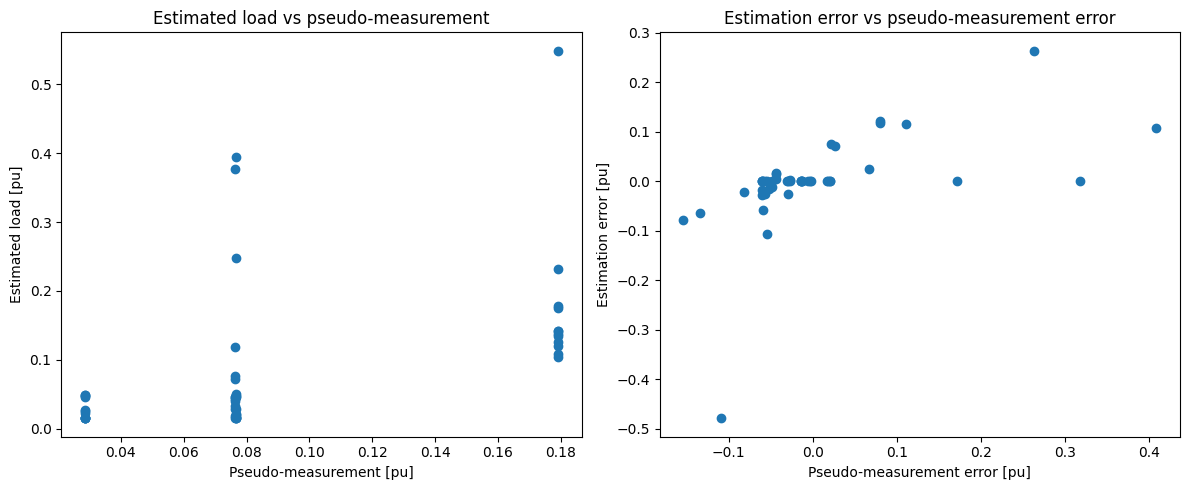

In [17]:
# ── Prepare plot arrays ───────────────────────────────────────────────────────
# yy1: pseudo-measurement values (same for all periods — the horizontal baseline)
# yy2: estimated actual currents = i^0 + Δî
# yy3: true deviations (how wrong the pseudo-measurement actually was)
# yy4: estimation error = true deviation − estimated deviation
yy1 = sp                        # shape (4,)
yy2 = sp + np.real(dx).T        # shape (m, 4)
yy3 = ds                        # shape (m, 4)
yy4 = ds - np.real(dx).T        # shape (m, 4)
 
# ── Figure 1: pseudo-measurement vs estimated load (like Fig. 49 left) ───────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for i in range(m):
    axes[0].plot(yy1, yy2[i, :], 'C0o')
axes[0].set_xlabel('Pseudo-measurement [pu]')
axes[0].set_ylabel('Estimated load [pu]')
axes[0].set_title('Estimated load vs pseudo-measurement')
 
# ── Figure 2: pseudo-measurement error vs estimation error (Fig. 49 right) ───
for i in range(m):
    axes[1].plot(yy3[i, :], yy4[i, :], 'C0o')
axes[1].set_xlabel('Pseudo-measurement error [pu]')
axes[1].set_ylabel('Estimation error [pu]')
axes[1].set_title('Estimation error vs pseudo-measurement error')
 
plt.tight_layout()
plt.show()

In [18]:
print("sp (pseudo-measurements):", sp)
print("\nA matrix:\n", A)
print("\nFor period 0:")
print("  zv (reference voltage):", zv)
print("  zv_t (real-time voltage):", mvp_t[:,3])  # run this inside the loop for i=0
print("  dv:", dv)
print("  dx[:,0]:", dx[:,0])
print("  s[0,:] (true loads):", s[0,:])

sp (pseudo-measurements): [0.17908333 0.02858333 0.07666667 0.07633333]

A matrix:
 [[ 0.02332532-0.01540064j  0.00526924+0.06912659j -0.125     -0.06j
   0.1038814 -0.06992786j]
 [ 0.02332532-0.01540064j  0.01053848+0.13825318j -0.0625    -0.03j
   0.1038814 -0.06992786j]
 [ 0.04665064-0.03080127j  0.00526924+0.06912659j -0.0625    -0.03j
   0.20776279-0.13985572j]]

For period 0:
  zv (reference voltage): [ 1.00256392-0.01072892j -0.49248567-0.87251786j -0.48057951+0.84937025j]
  zv_t (real-time voltage): [ 1.00631448-0.00319825j -0.49244873-0.86549546j -0.48460471+0.85781421j]
  dv: [ 3.75055991e-03+0.00753067j  3.69381063e-05+0.0070224j
 -4.02519898e-03+0.00844396j]
  dx[:,0]: [-0.07062392+0.00113529j -0.01358018-0.00014664j -0.02966288+0.00046521j
 -0.05749238+0.00041082j]
  s[0,:] (true loads): [0.045 0.015 0.047 0.033]


In [ ]:
rms_pm  = np.sqrt(np.mean(yy3**2, axis=0))
rms_est = np.sqrt(np.mean(yy4**2, axis=0))
improvement = (1 - rms_est/rms_pm) * 100

print("\nRMS error of pseudo-measurements:", rms_pm)
print("RMS error of estimates:", rms_est)
print("Improvement over pseudo-measurements:", improvement, "%")


RMS error of pseudo-measurements: [0.11586519 0.01412125 0.11392858 0.12760834]
RMS error of estimates: [1.76378028e-01 8.45455530e-06 3.66275236e-05 3.95524581e-02]


TypeError: unsupported format string passed to numpy.ndarray.__format__